# Paper 02 — Blandhol, Bonney, Mogstad & Torgovitsky: *When is TSLS Actually LATE?*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/iv/02-blandhol-bonney-mogstad-torgovitsky-tsls-late/simulation.ipynb)

See this folder's `README.md` for the 12-section explainer. This notebook is the runnable companion.

**What this simulation shows.** When the instrument $Z$ is only valid *conditional on* a covariate $X$ — and compliance + LATEs vary across strata of $X$ — the common empirical recipe

$$ \mathrm{ivreg}(Y \sim D + X \mid Z + X) $$

does **not** recover a non-negatively-weighted average of the stratum LATEs. A **saturated** specification that interacts $Z$ with $X$ does.

**Why conditional randomization matters.** If $Z$ were marginally independent of $X$, the unsaturated Wald would already equal the population LATE and there would be no bias. The Blandhol et al. critique hits the common case where $Z$ is only valid *once you condition on* $X$ — controlling for $X$ linearly is not enough.

**DGP highlights.**

- $X \sim \mathrm{Bernoulli}(0.5)$.
- $Z\,|\,X=0 \sim \mathrm{Bernoulli}(0.15)$; $Z\,|\,X=1 \sim \mathrm{Bernoulli}(0.55)$.
- $X=0$: complier share 0.20, stratum LATE = 3.0 (big effect, few compliers)
- $X=1$: complier share 0.60, stratum LATE = 0.0 (no effect, many compliers)
- Population LATE (target estimand, weighted by complier mass): $(0.10 \cdot 3.0 + 0.30 \cdot 0.0)/0.40 = 0.75$.

In [1]:
# On Colab: Runtime > Change runtime type > R. AER is not pre-installed on Colab's R
# runtime, so the line below installs it if missing (takes ~10s on a fresh kernel).
if (!requireNamespace('AER', quietly = TRUE)) install.packages('AER', quiet = TRUE)

suppressPackageStartupMessages({
  library(tidyverse)
  library(AER)
})

set.seed(20260421)

cat(sprintf('R          %s\n', paste(R.version$major, R.version$minor, sep='.')))
cat(sprintf('tidyverse  %s\n', packageVersion('tidyverse')))
cat(sprintf('AER        %s\n', packageVersion('AER')))

R          4.5.3
tidyverse  2.0.0
AER        1.2.16


## Parameters

In [2]:
N_SIM <- 500
N     <- 5000

# Compliance-type mix (always-taker, never-taker, complier), no defiers.
probs_X0 <- c(always = 0.10, never = 0.70, complier = 0.20)
probs_X1 <- c(always = 0.10, never = 0.30, complier = 0.60)

# P(Z=1 | X). Asymmetric on purpose — symmetric pZ would give identical
# Var(Z|X) across strata and unsaturated TSLS would coincidentally get
# the right LATE by accident. We want the weighting bug to be visible.
pZ_X0 <- 0.15
pZ_X1 <- 0.55

# Stratum-specific constant treatment effects.
tau_X0 <- 3.0
tau_X1 <- 0.0

# Population LATE, weighted by complier MASS:
#   mass_X0 = P(X=0) * complier share X=0 = 0.5 * 0.20 = 0.10
#   mass_X1 = P(X=1) * complier share X=1 = 0.5 * 0.60 = 0.30
true_LATE <- (0.10 * tau_X0 + 0.30 * tau_X1) / (0.10 + 0.30)   # = 0.75
cat(sprintf('true population LATE = %.2f\n', true_LATE))

true population LATE = 0.75


## One Monte Carlo draw

Fit three estimators on each draw:

1. **Unsaturated TSLS:** `ivreg(Y ~ D + X | Z + X)`.
2. **Stratum-Wise Wald** pooled by estimated complier mass.
3. **Full-interaction TSLS:** `ivreg(Y ~ D + X + D:X | Z + X + Z:X)`.

In [3]:
run_once <- function() {
  X <- rbinom(N, 1, 0.5)
  Z <- rbinom(N, 1, ifelse(X == 0, pZ_X0, pZ_X1))

  type <- character(N)
  type[X == 0] <- sample(c('always', 'never', 'complier'),
                         sum(X == 0), replace = TRUE, prob = probs_X0)
  type[X == 1] <- sample(c('always', 'never', 'complier'),
                         sum(X == 1), replace = TRUE, prob = probs_X1)

  D <- as.integer(type == 'always' | (type == 'complier' & Z == 1))

  eps <- rnorm(N, 0, 1)
  tau <- ifelse(X == 0, tau_X0, tau_X1)
  Y   <- ifelse(D == 1, tau + eps, eps)

  df <- tibble(Y = Y, D = D, Z = Z, X = X)

  # ---- Estimator 1: unsaturated TSLS -----------------------------------
  fit_unsat <- AER::ivreg(Y ~ D + X | Z + X, data = df)
  est_unsat <- unname(coef(fit_unsat)['D'])

  # ---- Estimator 2: stratum-wise Wald, pooled by complier mass ---------
  wald <- function(sub) {
    num <- mean(sub$Y[sub$Z == 1]) - mean(sub$Y[sub$Z == 0])
    den <- mean(sub$D[sub$Z == 1]) - mean(sub$D[sub$Z == 0])
    c(num = num, den = den, wald = num / den, size = nrow(sub))
  }
  w0 <- wald(dplyr::filter(df, X == 0))
  w1 <- wald(dplyr::filter(df, X == 1))
  mass0   <- (w0['size'] / N) * w0['den']
  mass1   <- (w1['size'] / N) * w1['den']
  est_sat <- unname((mass0 * w0['wald'] + mass1 * w1['wald']) / (mass0 + mass1))

  # ---- Estimator 3: full-interaction TSLS, pooled by complier mass -----
  df2 <- df |> mutate(DX = D * X, ZX = Z * X)
  fit_int  <- AER::ivreg(Y ~ D + X + DX | Z + X + ZX, data = df2)
  tau0_hat <- unname(coef(fit_int)['D'])
  tau1_hat <- unname(coef(fit_int)['D'] + coef(fit_int)['DX'])
  est_full <- unname((mass0 * tau0_hat + mass1 * tau1_hat) / (mass0 + mass1))

  c(
    unsat    = est_unsat,
    sat_wald = est_sat,
    full_int = est_full,
    wald_X0  = unname(w0['wald']),
    wald_X1  = unname(w1['wald'])
  )
}

## Monte Carlo

In [4]:
cat(sprintf('Running %d Monte Carlo draws (N = %d) ... ', N_SIM, N))
results <- replicate(N_SIM, run_once())
cat('done.\n\n')

mean_by_row <- function(m) apply(m, 1, mean)
sd_by_row   <- function(m) apply(m, 1, sd)

summary_tbl <- tibble(
  estimator     = c('Unsaturated TSLS (Y ~ D + X | Z + X)',
                    'Saturated: stratum Wald, pooled by complier mass',
                    'Saturated: full interaction TSLS, pooled',
                    'Stratum Wald at X=0 only',
                    'Stratum Wald at X=1 only'),
  truth         = c(true_LATE, true_LATE, true_LATE, tau_X0, tau_X1),
  mean_estimate = mean_by_row(results),
  mean_bias     = mean_by_row(results) - c(true_LATE, true_LATE, true_LATE, tau_X0, tau_X1),
  mc_sd         = sd_by_row(results)
)

cat('Monte Carlo summary:\n')
print(summary_tbl, n = Inf)

Running 500 Monte Carlo draws (N = 5000) ... done.

Monte Carlo summary:
# A tibble: 5 × 5
  estimator                                 truth mean_estimate mean_bias  mc_sd
  <chr>                                     <dbl>         <dbl>     <dbl>  <dbl>
1 Unsaturated TSLS (Y ~ D + X | Z + X)       0.75      0.442    -0.308    0.0881
2 Saturated: stratum Wald, pooled by compl…  0.75      0.751     0.00119  0.116 
3 Saturated: full interaction TSLS, pooled   0.75      0.751     0.00119  0.116 
4 Stratum Wald at X=0 only                   3         2.99     -0.00783  0.285 
5 Stratum Wald at X=1 only                   0         0.000370  0.000370 0.0683


## Diagnostic plot

Histograms of the three estimators across the Monte Carlo. The dashed line is the true population LATE (0.75). The dotted lines mark the two stratum LATEs (0.0 and 3.0). An unbiased estimator concentrates around the dashed line. Unsaturated TSLS concentrates well below 0.75; both saturated estimators concentrate on it.

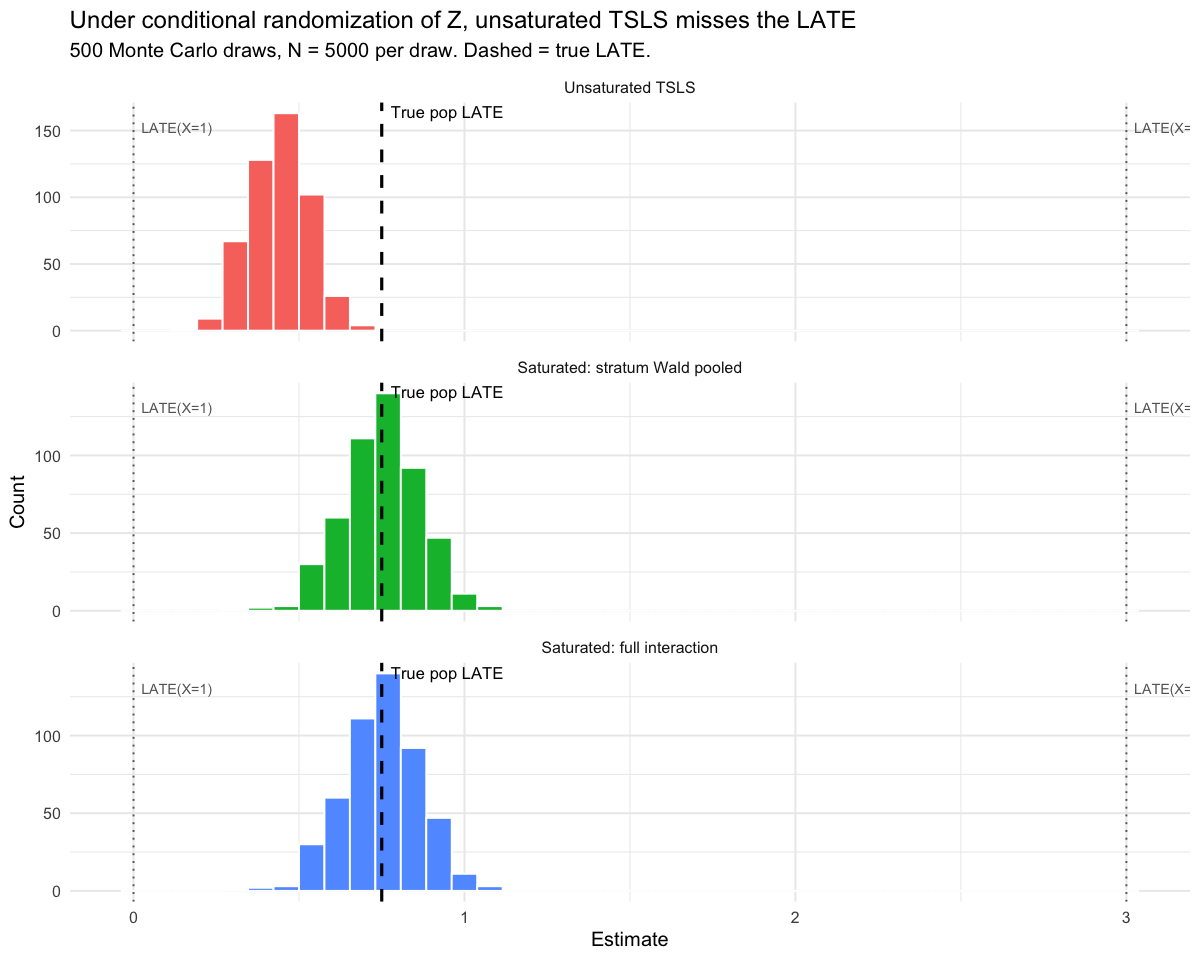

In [5]:
plot_df <- tibble(
  estimate = c(results['unsat', ], results['sat_wald', ], results['full_int', ]),
  estimator = factor(
    rep(c('Unsaturated TSLS',
          'Saturated: stratum Wald pooled',
          'Saturated: full interaction'),
        each = N_SIM),
    levels = c('Unsaturated TSLS',
               'Saturated: stratum Wald pooled',
               'Saturated: full interaction')
  )
)

options(repr.plot.width = 10, repr.plot.height = 8)

ggplot(plot_df, aes(x = estimate, fill = estimator)) +
  geom_histogram(bins = 40, colour = 'white') +
  geom_vline(xintercept = true_LATE, linetype = 'dashed', linewidth = 0.9) +
  geom_vline(xintercept = tau_X0, linetype = 'dotted', colour = 'grey40') +
  geom_vline(xintercept = tau_X1, linetype = 'dotted', colour = 'grey40') +
  annotate('text', x = true_LATE, y = Inf, label = '  True pop LATE',
           hjust = 0, vjust = 1.3, size = 3.5) +
  annotate('text', x = tau_X0, y = Inf, label = '  LATE(X=0)',
           hjust = 0, vjust = 3.0, size = 3, colour = 'grey40') +
  annotate('text', x = tau_X1, y = Inf, label = '  LATE(X=1)',
           hjust = 0, vjust = 3.0, size = 3, colour = 'grey40') +
  facet_wrap(~ estimator, ncol = 1, scales = 'free_y') +
  labs(
    title = 'Under conditional randomization of Z, unsaturated TSLS misses the LATE',
    subtitle = sprintf('%d Monte Carlo draws, N = %d per draw. Dashed = true LATE.', N_SIM, N),
    x = 'Estimate', y = 'Count'
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = 'none')

## Punchline

When the instrument is only valid **conditional on** $X$, you cannot recover the LATE by adding $X$ as a linear control in the TSLS. The first stage must be saturated: interact $Z$ with $X$ (and $D$ with $X$ in the structural equation) so every stratum of $X$ gets its own Wald estimate, which you then aggregate by complier mass.

**Blandhol et al.'s contribution** is to make the weighting explicit: unsaturated TSLS produces a weighted average of stratum LATEs, but with weights that depend on the first-stage strength per stratum — not on the complier mass you care about. When those two diverge (as they do here by construction), TSLS is not even a positively-weighted average of LATEs.